In [1]:
import scanpy as sc
import pandas as pd
import plotly.graph_objects as go

In [4]:
obs = sc.read_h5ad('/lustre/groups/ml01/workspace/hpca/hpca_downstream//2026_final_object.h5ad').obs

In [5]:
hierarchy = obs[['Level_1', 'Level_2', 'Level_3', 'Level_4']]

In [6]:
hierarchy['Level_1'] = '1: '+hierarchy['Level_1'].astype('str')
hierarchy['Level_2'] = '2: '+hierarchy['Level_2'].astype('str')
hierarchy['Level_3'] = '3: '+hierarchy['Level_3'].astype('str')
hierarchy['Level_4'] = '4: '+hierarchy['Level_4'].astype('str')

/tmp/ipykernel_2776180/1670530121.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hierarchy['Level_1'] = '1: '+hierarchy['Level_1'].astype('str')
/tmp/ipykernel_2776180/1670530121.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hierarchy['Level_2'] = '2: '+hierarchy['Level_2'].astype('str')
/tmp/ipykernel_2776180/1670530121.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the 

In [7]:
df = hierarchy

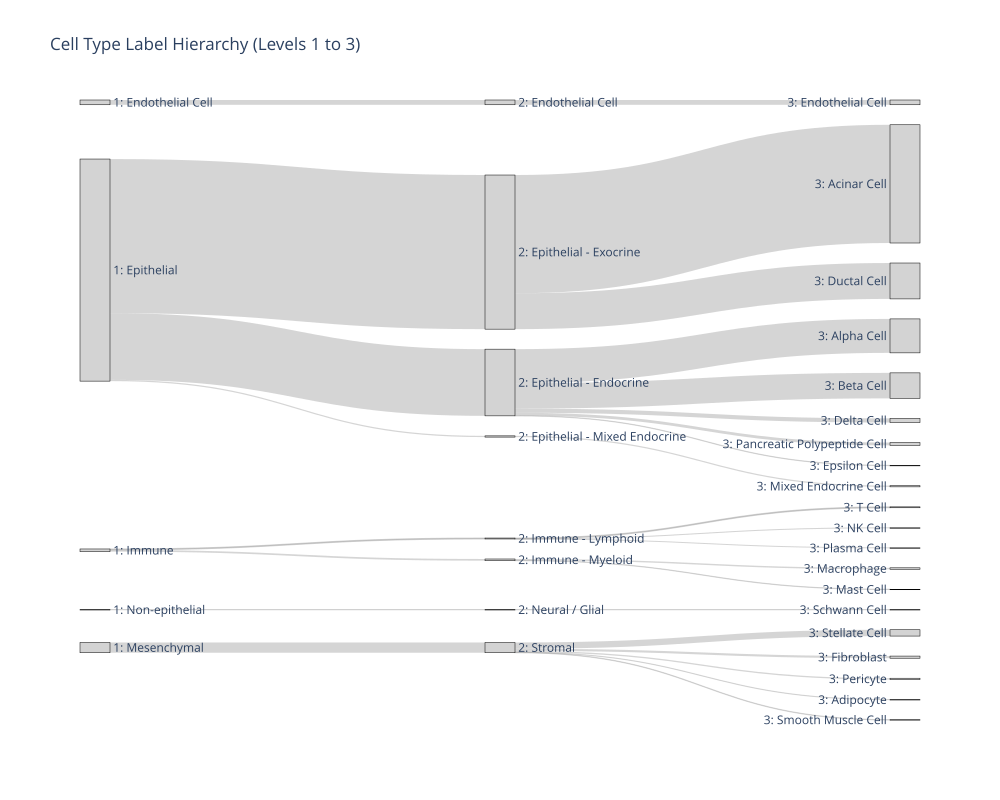

In [8]:


# Assuming your dataframe is 'df' and has columns: 'Level_1', 'Level_2', 'Level_3'
# (Replace these with your actual column names if they are different)

# 1. Aggregate the links for Level 1 -> Level 2
# This counts how many cells/rows go from each L1 category to each L2 category
links_1 = df.groupby(['Level_1', 'Level_2']).size().reset_index(name='value')
links_1.columns = ['source', 'target', 'value']

# 2. Aggregate the links for Level 2 -> Level 3
links_2 = df.groupby(['Level_2', 'Level_3']).size().reset_index(name='value')
links_2.columns = ['source', 'target', 'value']

# 3. Combine them into a single list of all connections
links = pd.concat([links_1, links_2], axis=0, ignore_index=True)

# 4. Create a unique integer ID for every single node in the plot
# Plotly requires nodes to be numbers (0, 1, 2...), not strings
unique_nodes = list(pd.unique(links[['source', 'target']].values.ravel('K')))
node_mapping = {node: i for i, node in enumerate(unique_nodes)}

# 5. Map the string names to their new integer IDs
links['source_idx'] = links['source'].map(node_mapping)
links['target_idx'] = links['target'].map(node_mapping)

# 6. Build the Plotly Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=20,          # Space between nodes vertically
        thickness=30,    # Width of the node blocks
        line=dict(color="black", width=0.5),
        label=unique_nodes, # The actual text labels
        color="lightgray"   # You can customize node colors here
    ),
    link=dict(
        source=links['source_idx'],
        target=links['target_idx'],
        value=links['value'],
        # Optional: Make the links slightly transparent
        color="rgba(150, 150, 150, 0.4)" 
    )
)])

# Update layout for a cleaner look
fig.update_layout(
    title_text="Cell Type Label Hierarchy (Levels 1 to 3)", 
    font_size=12,
    width=1000,
    height=800
)

fig.show(renderer='svg')
fig.write_image('/lustre/groups/ml01/workspace/hpca/hpca_downstream/label_technology_mixing/sankey_label_hierarchy.svg')

In [28]:
df.loc[df.Level_4_refined_desc == '4: Acinar Cell/Ductal positive [SLC4A4_pos]', 'Level_3'] = '3: Acinar/Ductal Cell'

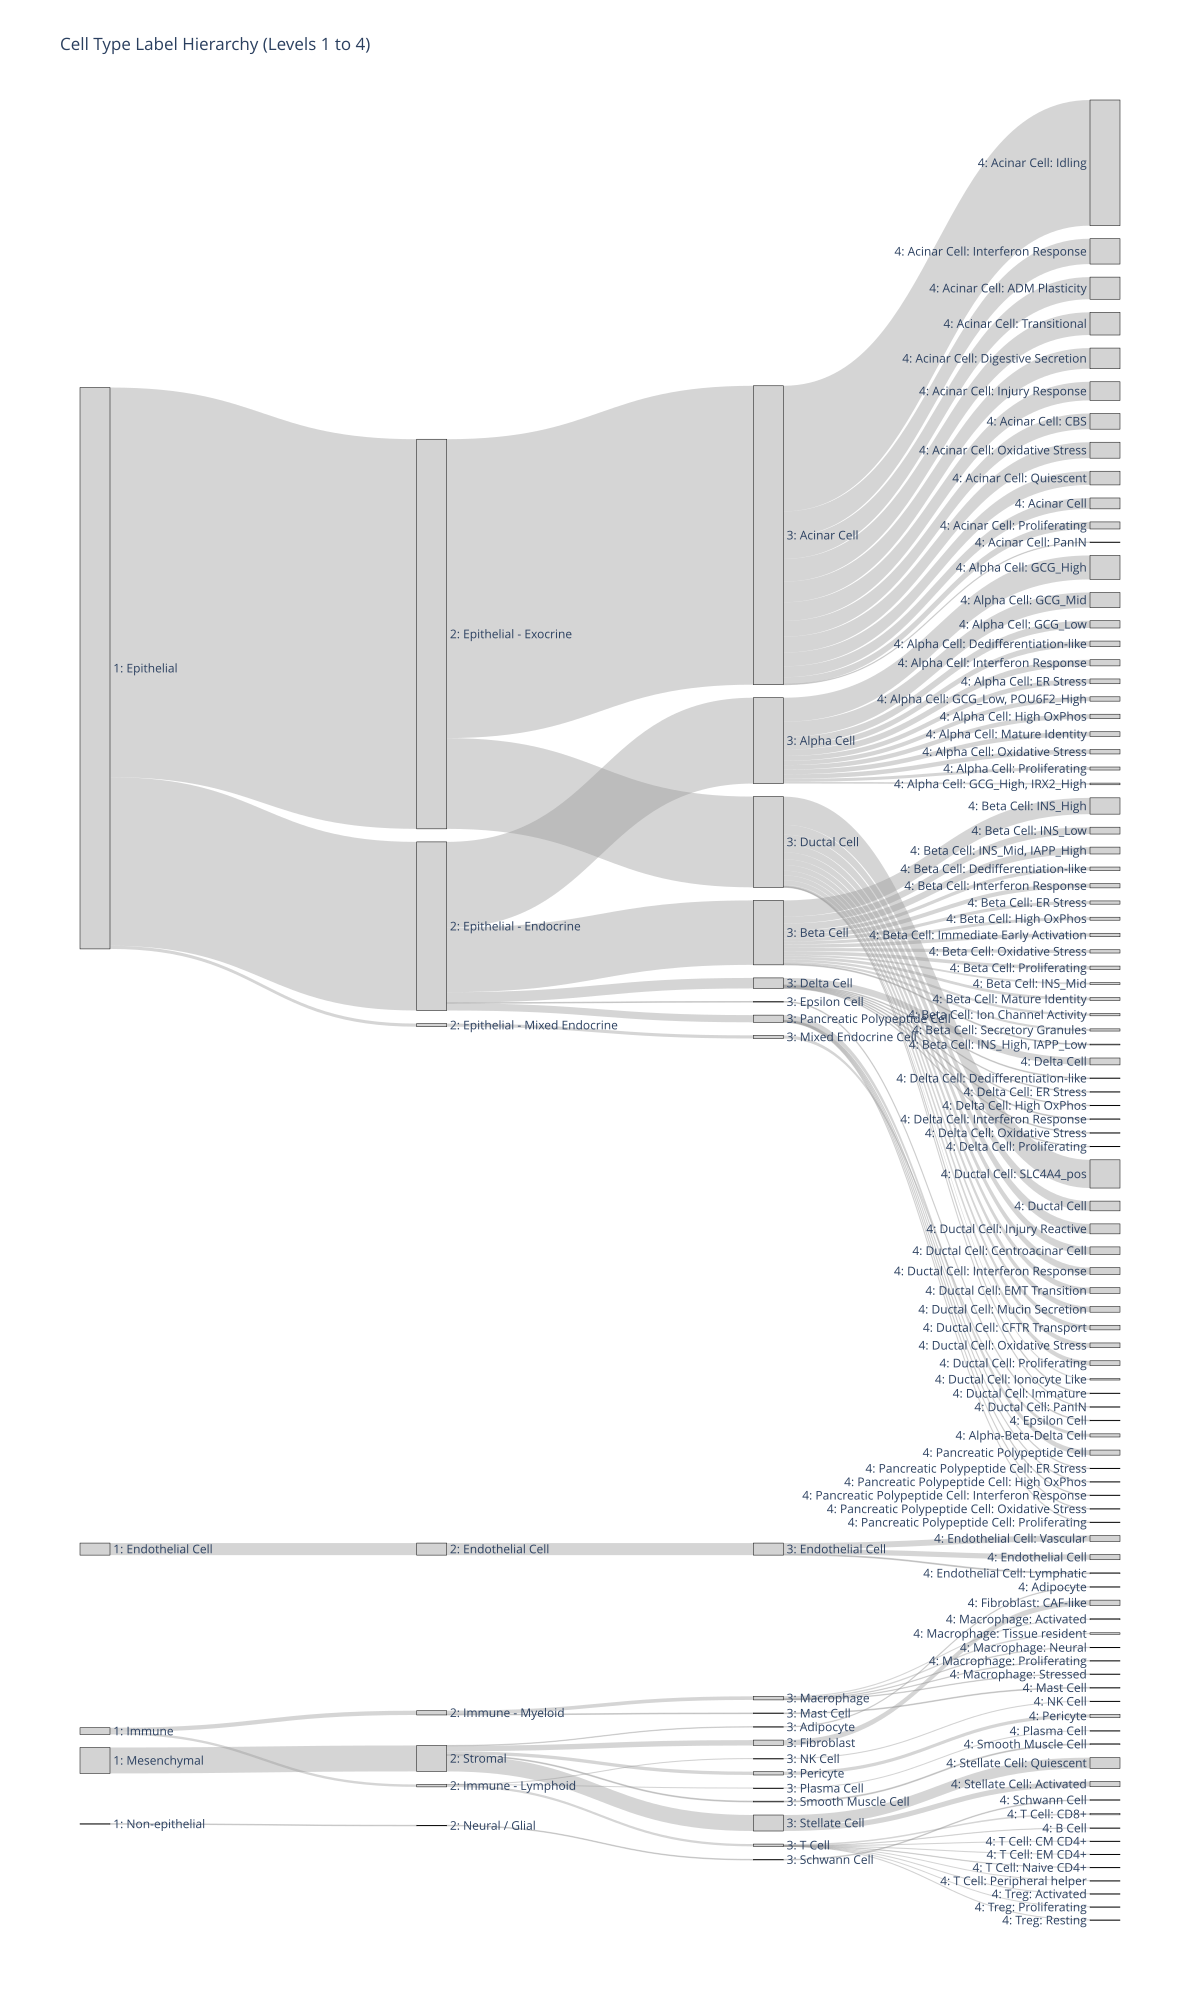

In [11]:


# Assuming your dataframe is 'df' and has columns: 'Level_1', 'Level_2', 'Level_3'
# (Replace these with your actual column names if they are different)

# 1. Aggregate the links for Level 1 -> Level 2
# This counts how many cells/rows go from each L1 category to each L2 category
links_1 = df.groupby(['Level_1', 'Level_2']).size().reset_index(name='value')
links_1.columns = ['source', 'target', 'value']

# 2. Aggregate the links for Level 2 -> Level 3
links_2 = df.groupby(['Level_2', 'Level_3']).size().reset_index(name='value')
links_2.columns = ['source', 'target', 'value']

# 2. Aggregate the links for Level 2 -> Level 4
links_3 = df.groupby(['Level_3', 'Level_4']).size().reset_index(name='value')
links_3.columns = ['source', 'target', 'value']

# 3. Combine them into a single list of all connections
links = pd.concat([links_1, links_2, links_3], axis=0, ignore_index=True)

# 4. Create a unique integer ID for every single node in the plot
# Plotly requires nodes to be numbers (0, 1, 2...), not strings
unique_nodes = list(pd.unique(links[['source', 'target']].values.ravel('K')))
node_mapping = {node: i for i, node in enumerate(unique_nodes)}

# 5. Map the string names to their new integer IDs
links['source_idx'] = links['source'].map(node_mapping)
links['target_idx'] = links['target'].map(node_mapping)

# 6. Build the Plotly Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=20,          # Space between nodes vertically
        thickness=30,    # Width of the node blocks
        line=dict(color="black", width=0.5),
        label=unique_nodes, # The actual text labels
        color="lightgray"   # You can customize node colors here
    ),
    link=dict(
        source=links['source_idx'],
        target=links['target_idx'],
        value=links['value'],
        # Optional: Make the links slightly transparent
        color="rgba(150, 150, 150, 0.4)" 
    )
)])

# Update layout for a cleaner look
fig.update_layout(
    title_text="Cell Type Label Hierarchy (Levels 1 to 4)", 
    font_size=12,
    width=1200,
    height=2000
)

fig.show(renderer='svg')
fig.write_image('/lustre/groups/ml01/workspace/hpca/hpca_downstream/label_technology_mixing/sankey_label_hierarchy_l4.svg')